
Step 1: Import Libraries



In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import numpy as np
from tensorflow.keras.preprocessing import image

Extract ZIP File

In [5]:
import zipfile
import os

zip_path = "/content/archive (3).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done!")

Extraction Done!


Check Folder Structure

In [6]:
for root, dirs, files in os.walk(extract_path):
    print(root)
    break

/content/dataset


Set Correct Paths

In [8]:
train_dir = "/content/dataset/Training"
test_dir = "/content/dataset/Testing"

In [9]:
os.listdir("/content/dataset")

['Testing', 'Training']

Data Preprocessing

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_data = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    shuffle=False
)

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


Build CNN Model

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(4, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [47]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [13]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 247s 3s/step - accuracy: 0.5738 - loss: 1.0283 - val_accuracy: 0.5096 - val_loss: 1.0519
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 259s 4s/step - accuracy: 0.7606 - loss: 0.6108 - val_accuracy: 0.5881 - val_loss: 0.9801
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 247s 3s/step - accuracy: 0.8450 - loss: 0.4086 - val_accuracy: 0.5532 - val_loss: 1.0574
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.8946 - loss: 0.2733 - val_accuracy: 0.6475 - val_loss: 0.9917
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 240s 3s/step - accuracy: 0.9221 - loss: 0.2158 - val_accuracy: 0.7400 - val_loss: 0.8604
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 239s 3s/step - accuracy: 0.9377 - loss: 0.1710 - val_accuracy: 0.7138 - val_loss: 1.0682
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.9417 - loss: 0.1527 - val_accuracy: 0.7539 - val_loss: 1.0200
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 247s 3s/step - accuracy: 0.9552 - loss: 0.1117 - val_accuracy: 0.6614 - v

Evaluate Model

In [14]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 902ms/step - accuracy: 0.7030 - loss: 3.4612
Test Accuracy: 0.703045666217804


Confusion Matrix

13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step


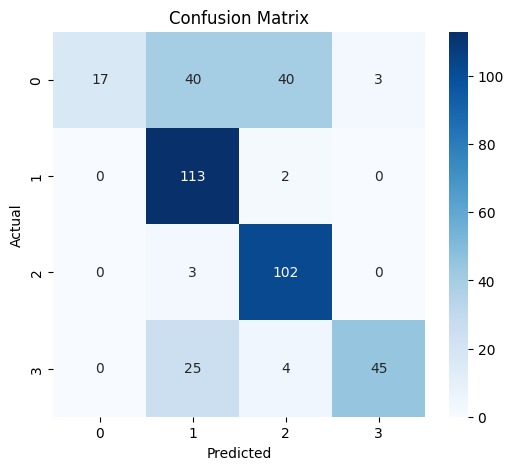

In [27]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = test_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Classification Report

In [30]:
from sklearn.metrics import classification_report

labels = list(train_data.class_indices.keys())

print(classification_report(y_true, y_pred_classes, target_names=labels))

                  precision    recall  f1-score   support

    glioma_tumor       1.00      0.17      0.29       100
meningioma_tumor       0.62      0.98      0.76       115
        no_tumor       0.69      0.97      0.81       105
 pituitary_tumor       0.94      0.61      0.74        74

        accuracy                           0.70       394
       macro avg       0.81      0.68      0.65       394
    weighted avg       0.80      0.70      0.65       394



Class Labels

In [15]:
class_labels = train_data.class_indices
print(class_labels)

{'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


Stage Mapping

In [16]:
stage_mapping = {
    'no_tumor': "Stage 0 (Healthy)",
    'meningioma_tumor': "Stage 1",
    'pituitary_tumor': "Stage 2",
    'glioma_tumor': "Stage 3"
}

Prediction Code

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    # Load image
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array_exp = np.expand_dims(img_array, axis=0)

    # Prediction
    prediction = model.predict(img_array_exp)
    class_index = np.argmax(prediction)

    labels = {v:k for k,v in class_labels.items()}
    predicted_class = labels[class_index]

    confidence = np.max(prediction)
    stage = stage_mapping[predicted_class]

    # Show image
    plt.imshow(img_array)
    plt.axis('off')

    # Title with results
    plt.title(
        f"Tumor: {predicted_class}\nStage: {stage}\nConfidence: {confidence:.2f}",
        color='red',
        fontsize=12
    )

    plt.show()

    # Also print (optional)
    print("Tumor Type:", predicted_class)
    print("Tumor Stage:", stage)
    print("Confidence:", confidence)

Result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


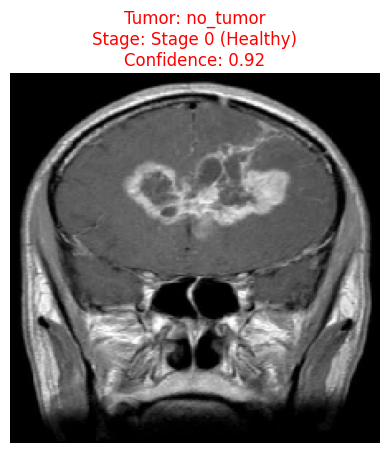

Tumor Type: no_tumor
Tumor Stage: Stage 0 (Healthy)
Confidence: 0.91562146


In [32]:
predict_image("/content/dataset/Testing/glioma_tumor/image(1).jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


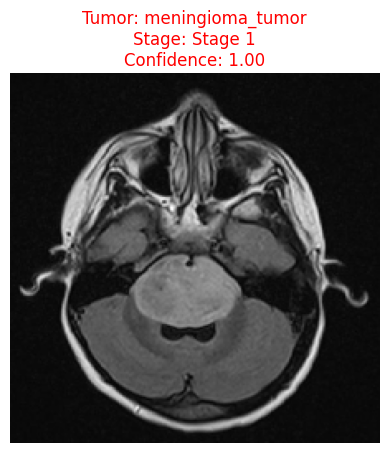

Tumor Type: meningioma_tumor
Tumor Stage: Stage 1
Confidence: 0.99727744


In [33]:
predict_image("/content/dataset/Testing/glioma_tumor/image(2).jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


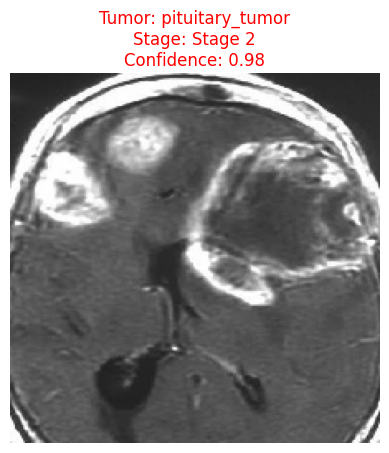

Tumor Type: pituitary_tumor
Tumor Stage: Stage 2
Confidence: 0.9783911


In [36]:
predict_image("/content/dataset/Testing/glioma_tumor/image(5).jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


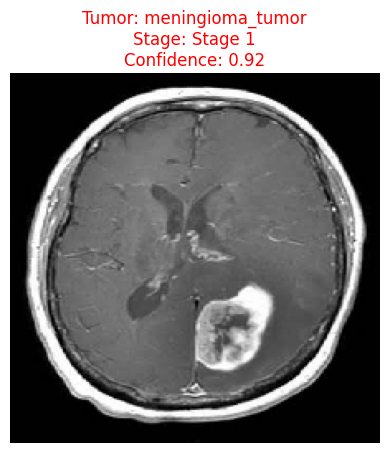

Tumor Type: meningioma_tumor
Tumor Stage: Stage 1
Confidence: 0.91635853


In [43]:
predict_image("/content/dataset/Testing/glioma_tumor/image(40).jpg")